# Exploratory Data Analysis for Monthly SNOTEL SWE Prediction

This notebook explores the cleansed monthly SNOTEL dataset that will be used to predict next-month snow water equivalent (`target_swe_next_month`). The goal is to understand data quality, missingness, station coverage, seasonal behavior, feature-target relationships, and modeling risks before building a regression model.


## 1. Setup

This section imports the analysis libraries, sets display/plot defaults, and defines small helper functions used throughout the notebook.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

DATA_PATH = Path('../cleansed_data/cleansed_dataset.csv')
TARGET = 'target_swe_next_month'
DATE_COLS = ['month_end', 'target_month_end', 'beginDate', 'endDate']
ID_COLS = ['station_triplet', 'name', 'stateCode', 'countyName', 'huc']

def display_section(title):
    print('\n' + '=' * len(title))
    print(title)
    print('=' * len(title))

def missing_table(data):
    missing = data.isna().sum().rename('missing_count').to_frame()
    missing['missing_pct'] = missing['missing_count'] / len(data) * 100
    missing['dtype'] = data.dtypes.astype(str)
    return missing.sort_values(['missing_pct', 'missing_count'], ascending=False)

def numeric_summary(data, cols):
    return data[cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

def rmse(y_true, y_pred):
    err = y_true - y_pred
    return float(np.sqrt(np.mean(err ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def r2_score(y_true, y_pred):
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return np.nan if ss_tot == 0 else 1 - ss_res / ss_tot


## 2. Load the Cleansed Dataset

The preprocessing notebook writes a modeling-ready CSV to `cleansed_data/`. This section loads that file, removes export-only index columns, parses dates, and checks the basic shape of the data.


In [ ]:
df = pd.read_csv(DATA_PATH)

unnamed_cols = [col for col in df.columns if col.startswith('Unnamed')]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

for col in DATE_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]:,}')
print(f'Duplicate rows: {df.duplicated().sum():,}')
print(f'Date range: {df["month_end"].min().date()} to {df["month_end"].max().date()}')
print(f'Target date range: {df["target_month_end"].min().date()} to {df["target_month_end"].max().date()}')

df.head()


Rows: 88,049
Columns: 52
Duplicate rows: 0
Date range: 2007-01-31 to 2025-11-30
Target date range: 2007-02-28 to 2025-12-31


,station_triplet,month_end,current_swe,WTEQ_mean,WTEQ_min,WTEQ_max,current_snow_depth,SNWD_mean,SNWD_min,SNWD_max,monthly_precip,TAVG_mean,TAVG_min,TAVG_max,TAVG_std,TMIN_mean,TMIN_min,TMAX_mean,TMAX_max,month,year,day_of_year,month_sin,month_cos,is_winter,is_spring,water_year,swe_lag_1,swe_lag_2,swe_lag_3,snow_depth_lag_1,precip_lag_1,precip_lag_2,precip_rolling_3mo,swe_change_1mo,swe_change_2mo,water_year_precip_to_date,water_year_max_swe_so_far,avg_temp_above_freezing,freeze_thaw_risk,target_swe_next_month,target_month_end,name,stateCode,countyName,huc,elevation,latitude,longitude,beginDate,endDate,historical_target_swe_median
0,1000:OR:SNTL,2007-01-31,23.500,23.013,18.800,23.900,63.000,66.806,58.000,74.000,4.500,23.887,7.200,34.700,7.047,13.958,-6.700,38.055,51.300,1,2007,31,0.500,0.866,1,0,2007,18.800,8.200,0.000,60.000,14.900,17.400,36.800,4.700,15.300,37.700,23.500,0,1,33.800,2007-02-28,Annie Springs,OR,Klamath,180102030101,"6,020.000",42.870,-122.165,2000-09-01,2100-01-01,52.600
1,1000:OR:SNTL,2007-02-28,33.800,26.707,23.200,33.800,115.000,77.786,61.000,115.000,10.300,27.654,17.800,38.100,5.940,21.379,9.300,35.493,54.000,2,2007,59,0.866,0.500,1,0,2007,23.500,18.800,8.200,63.000,4.500,14.900,29.700,10.300,15.000,48.000,33.800,0,1,36.600,2007-03-31,Annie Springs,OR,Klamath,180102030101,"6,020.000",42.870,-122.165,2000-09-01,2100-01-01,63.100
2,1000:OR:SNTL,2007-03-31,36.600,35.968,34.300,36.800,78.000,89.774,78.000,115.000,4.200,33.984,22.100,42.600,5.919,24.113,11.100,46.977,65.700,3,2007,90,1.000,0.000,0,1,2007,33.800,23.500,18.800,115.000,10.300,4.500,19.000,2.800,13.100,52.200,36.600,1,1,35.200,2007-04-30,Annie Springs,OR,Klamath,180102030101,"6,020.000",42.870,-122.165,2000-09-01,2100-01-01,68.000
3,1000:OR:SNTL,2007-10-31,0.000,0.145,0.000,0.800,0.000,1.258,0.000,8.000,8.400,36.055,27.900,43.900,4.668,28.316,16.700,46.681,63.700,10,2007,304,-0.866,0.500,0,0,2008,0.000,0.000,0.000,0.000,1.000,1.100,10.500,0.000,0.000,8.400,0.000,1,1,1.600,2007-11-30,Annie Springs,OR,Klamath,180102030101,"6,020.000",42.870,-122.165,2000-09-01,2100-01-01,8.200
4,1000:OR:SNTL,2007-11-30,1.600,0.423,0.000,1.600,10.000,2.800,0.000,11.000,8.700,32.030,13.500,42.100,8.087,23.147,6.300,44.803,67.300,11,2007,334,-0.500,0.866,0,0,2008,0.000,0.000,0.000,0.000,8.400,1.000,18.100,1.600,1.600,17.100,1.600,1,1,12.300,2007-12-31,Annie Springs,OR,Klamath,180102030101,"6,020.000",42.870,-122.165,2000-09-01,2100-01-01,18.800


## 3. Dataset Scope and Coverage

Before looking at feature relationships, it is important to understand the observational unit: one station-month used to predict the next month-end SWE. This section summarizes station coverage, target months, geography, and temporal span.


rows                                    88049
columns                                    52
stations                                  858
states                                     13
counties                                  196
first_month_end           2007-01-31 00:00:00
last_month_end            2025-11-30 00:00:00
first_target_month_end    2007-02-28 00:00:00
last_target_month_end     2025-12-31 00:00:00
dtype: object

Target months kept in this modeling dataset:


,rows
target_month,
1,14208
2,14038
3,14897
4,14905
11,14952
12,15049



Station Row Count Summary


,row_count
count,858.000
mean,102.621
std,21.206
min,12.000
1%,18.000
5%,54.000
25%,112.000
50%,112.000
75%,112.000
95%,112.000


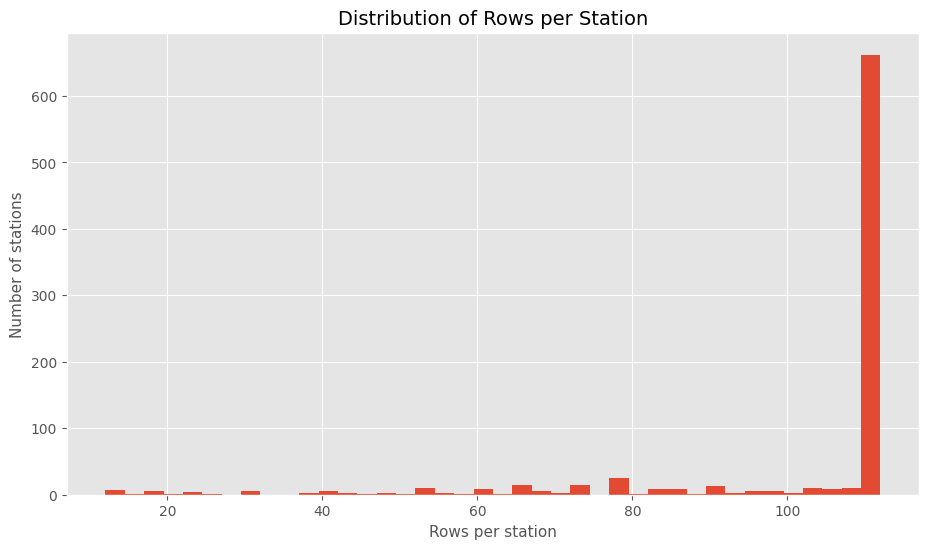

In [ ]:
overview = pd.Series({
    'rows': len(df),
    'columns': df.shape[1],
    'stations': df['station_triplet'].nunique(),
    'states': df['stateCode'].nunique(),
    'counties': df['countyName'].nunique(),
    'first_month_end': df['month_end'].min(),
    'last_month_end': df['month_end'].max(),
    'first_target_month_end': df['target_month_end'].min(),
    'last_target_month_end': df['target_month_end'].max(),
})
display(overview)

print('Target months kept in this modeling dataset:')
display(
    df.assign(target_month=df['target_month_end'].dt.month)
      .groupby('target_month')
      .size()
      .rename('rows')
      .to_frame()
)

station_counts = df.groupby('station_triplet').size().rename('row_count')
display_section('Station Row Count Summary')
display(station_counts.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame())

fig, ax = plt.subplots()
station_counts.hist(bins=40, ax=ax)
ax.set_title('Distribution of Rows per Station')
ax.set_xlabel('Rows per station')
ax.set_ylabel('Number of stations')
plt.show()


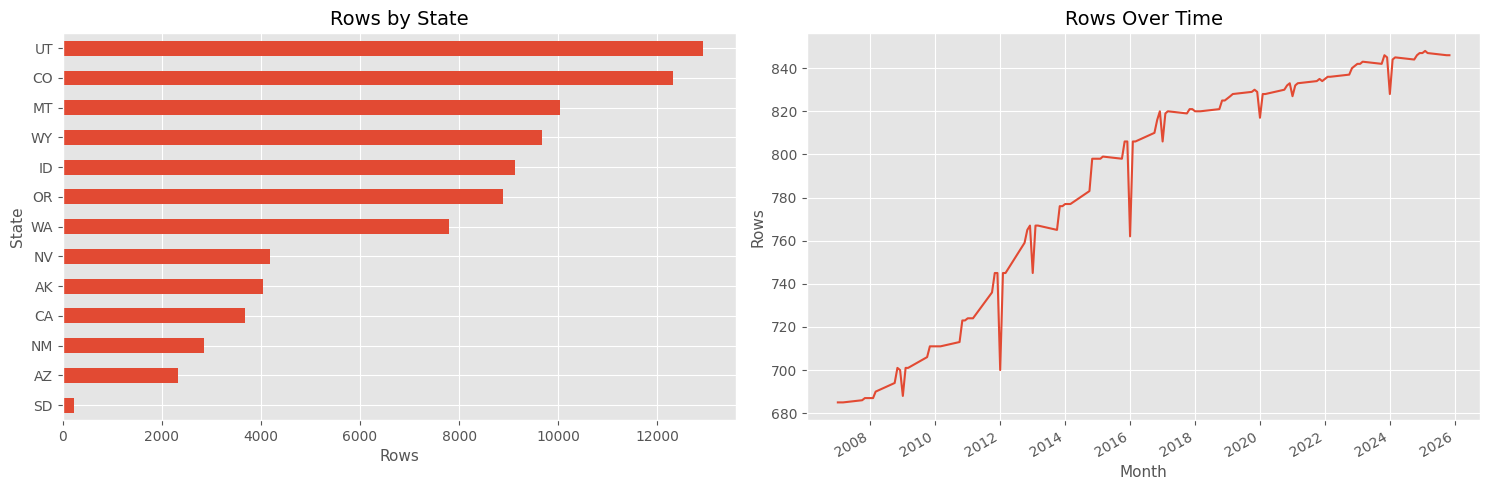

,rows,stations,mean_target_swe,median_target_swe,mean_elevation
stateCode,,,,,
UT,12931,135,8.757,6.800,"8,629.921"
CO,12324,116,9.875,8.300,"10,133.839"
MT,10030,92,11.278,8.500,"6,861.904"
WY,9666,89,10.670,8.400,"8,626.982"
ID,9135,83,12.586,9.700,"6,486.212"
OR,8890,81,9.770,6.200,"4,945.675"
WA,7789,76,19.010,13.900,"4,320.048"
NV,4179,44,7.124,5.000,"7,753.317"
AK,4040,54,8.116,5.400,"1,488.230"


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

state_counts = df['stateCode'].value_counts().sort_values(ascending=True)
state_counts.plot(kind='barh', ax=axes[0])
axes[0].set_title('Rows by State')
axes[0].set_xlabel('Rows')
axes[0].set_ylabel('State')

monthly_counts = df.groupby(df['month_end'].dt.to_period('M')).size()
monthly_counts.index = monthly_counts.index.to_timestamp()
monthly_counts.plot(ax=axes[1])
axes[1].set_title('Rows Over Time')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Rows')

plt.tight_layout()
plt.show()

coverage_by_state = (
    df.groupby('stateCode')
      .agg(
          rows=('station_triplet', 'size'),
          stations=('station_triplet', 'nunique'),
          mean_target_swe=(TARGET, 'mean'),
          median_target_swe=(TARGET, 'median'),
          mean_elevation=('elevation', 'mean'),
      )
      .sort_values('rows', ascending=False)
)
display(coverage_by_state)


## 4. Missing Data Analysis

Missingness can create biased models or silently reduce the training set. This section identifies remaining missing values, checks whether missingness varies by time/state/month, and flags columns that may need imputation or removal.


,missing_count,missing_pct,dtype
current_snow_depth,1810,2.056,float64
SNWD_mean,1810,2.056,float64
SNWD_min,1810,2.056,float64
SNWD_max,1810,2.056,float64
snow_depth_lag_1,1771,2.011,float64
TMAX_mean,783,0.889,float64
TMAX_max,783,0.889,float64
TMIN_mean,726,0.825,float64
TMIN_min,726,0.825,float64
TAVG_std,483,0.549,float64


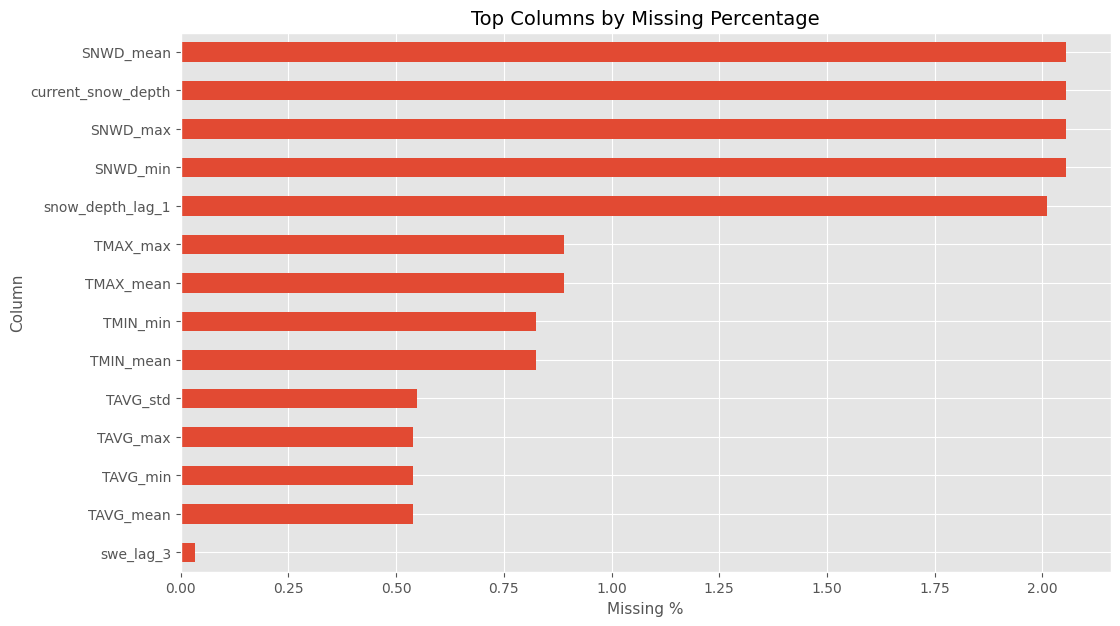

Target missing count: 0
Historical target median missing count: 0


In [ ]:
miss = missing_table(df)
display(miss.head(30))

fig, ax = plt.subplots(figsize=(12, 7))
miss_nonzero = miss[miss['missing_count'] > 0].head(30).sort_values('missing_pct')
if len(miss_nonzero) > 0:
    miss_nonzero['missing_pct'].plot(kind='barh', ax=ax)
    ax.set_title('Top Columns by Missing Percentage')
    ax.set_xlabel('Missing %')
    ax.set_ylabel('Column')
else:
    ax.text(0.5, 0.5, 'No missing values detected', ha='center', va='center', transform=ax.transAxes)
    ax.set_axis_off()
plt.show()

print(f'Target missing count: {df[TARGET].isna().sum():,}')
print(f'Historical target median missing count: {df["historical_target_swe_median"].isna().sum():,}')


,avg_cell_missing_pct
target_month,
1,0.293
2,0.307
3,0.345
4,0.334
11,0.273
12,0.279


,avg_cell_missing_pct
stateCode,
AK,1.181
ID,0.958
WY,0.538
NM,0.271
WA,0.218
UT,0.189
NV,0.180
AZ,0.146
CO,0.097


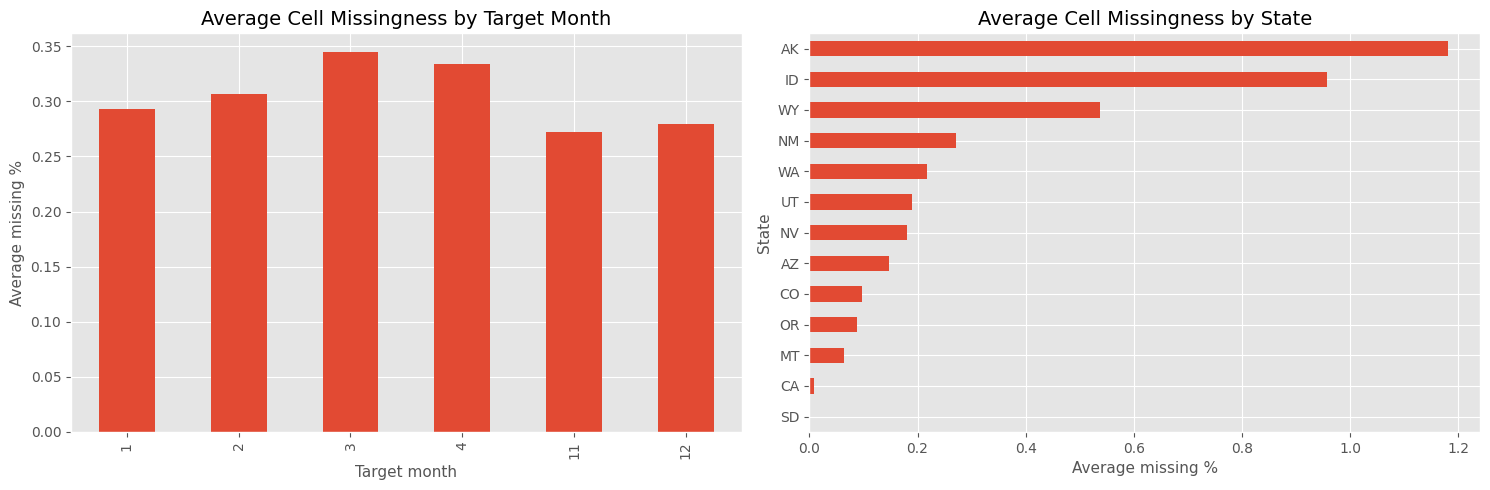

In [ ]:
missing_by_month = (
    df.assign(target_month=df['target_month_end'].dt.month)
      .groupby('target_month')
      .apply(lambda g: g.isna().mean().mean() * 100, include_groups=False)
      .rename('avg_cell_missing_pct')
      .to_frame()
)
display(missing_by_month)

missing_by_state = (
    df.groupby('stateCode')
      .apply(lambda g: g.isna().mean().mean() * 100, include_groups=False)
      .rename('avg_cell_missing_pct')
      .sort_values(ascending=False)
      .to_frame()
)
display(missing_by_state.head(20))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
missing_by_month['avg_cell_missing_pct'].plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Cell Missingness by Target Month')
axes[0].set_xlabel('Target month')
axes[0].set_ylabel('Average missing %')

missing_by_state['avg_cell_missing_pct'].sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('Average Cell Missingness by State')
axes[1].set_xlabel('Average missing %')
axes[1].set_ylabel('State')
plt.tight_layout()
plt.show()


## 5. Target Variable EDA

The target is next-month SWE at month end. Regression model choice and evaluation will depend heavily on the target distribution, zero inflation, seasonal behavior, and extreme high-SWE cases.


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
target_swe_next_month,"88,049.000",10.560,11.020,0.000,0.000,0.000,3.000,7.500,14.400,32.200,51.900,123.700


Zero target SWE rows: 7,472 (8.49%)


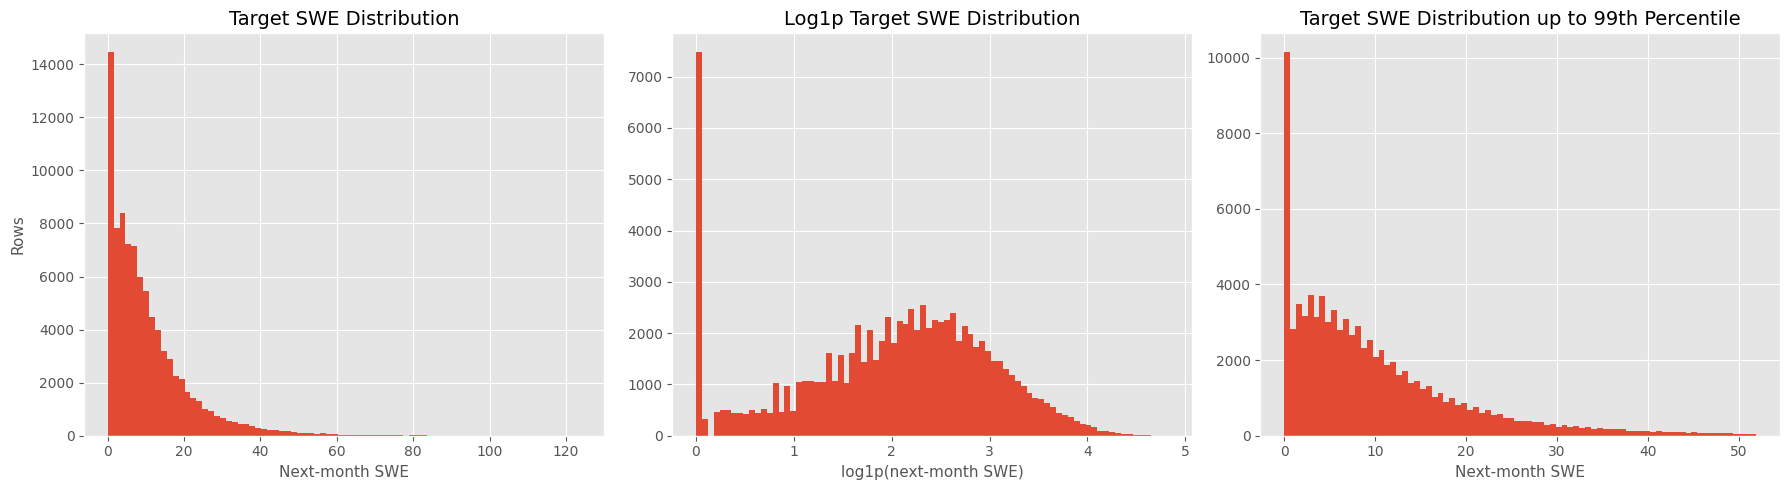

In [ ]:
display(numeric_summary(df, [TARGET]))

zero_target_pct = (df[TARGET] == 0).mean() * 100
print(f'Zero target SWE rows: {(df[TARGET] == 0).sum():,} ({zero_target_pct:.2f}%)')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df[TARGET].hist(bins=80, ax=axes[0])
axes[0].set_title('Target SWE Distribution')
axes[0].set_xlabel('Next-month SWE')
axes[0].set_ylabel('Rows')

np.log1p(df[TARGET]).hist(bins=80, ax=axes[1])
axes[1].set_title('Log1p Target SWE Distribution')
axes[1].set_xlabel('log1p(next-month SWE)')

upper = df[TARGET].quantile(0.99)
df.loc[df[TARGET] <= upper, TARGET].hist(bins=80, ax=axes[2])
axes[2].set_title('Target SWE Distribution up to 99th Percentile')
axes[2].set_xlabel('Next-month SWE')

plt.tight_layout()
plt.show()


,rows,mean,median,std,min,p95,max,zero_pct
target_month,,,,,,,,
1,14208,10.609,8.700,7.666,0.000,25.600,80.200,1.753
2,14038,13.980,11.600,10.084,0.000,33.700,94.200,2.009
3,14897,16.455,13.600,13.369,0.000,42.600,118.600,7.700
4,14905,12.970,8.900,15.051,0.000,42.900,123.700,26.964
11,14952,2.794,2.200,2.622,0.000,7.800,28.600,9.524
12,15049,6.817,5.600,5.202,0.000,16.900,48.700,2.332


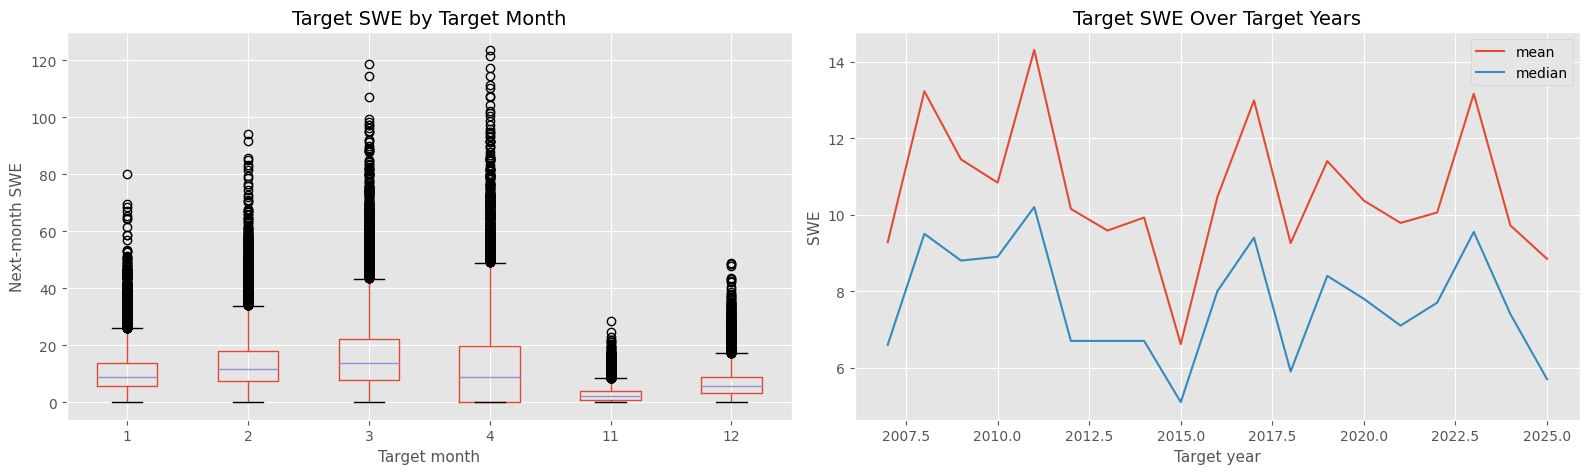

In [ ]:
target_by_month = (
    df.assign(target_month=df['target_month_end'].dt.month)
      .groupby('target_month')[TARGET]
      .agg(rows='size', mean='mean', median='median', std='std', min='min', p95=lambda s: s.quantile(0.95), max='max', zero_pct=lambda s: (s == 0).mean() * 100)
)
display(target_by_month)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df.assign(target_month=df['target_month_end'].dt.month).boxplot(column=TARGET, by='target_month', ax=axes[0])
axes[0].set_title('Target SWE by Target Month')
axes[0].set_xlabel('Target month')
axes[0].set_ylabel('Next-month SWE')

annual_target = df.groupby(df['target_month_end'].dt.year)[TARGET].agg(['mean', 'median'])
annual_target.plot(ax=axes[1])
axes[1].set_title('Target SWE Over Target Years')
axes[1].set_xlabel('Target year')
axes[1].set_ylabel('SWE')

plt.suptitle('')
plt.tight_layout()
plt.show()


## 6. Feature Inventory

This section organizes columns into numeric, categorical, date, and likely modeling-excluded identifiers. The numeric feature inventory is used for correlations, outlier screening, and feature deep dives.


In [ ]:
all_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
all_categorical_cols = df.select_dtypes(exclude=[np.number, 'datetime64[ns]']).columns.tolist()
all_datetime_cols = df.select_dtypes(include=['datetime64[ns]']).columns.tolist()

excluded_numeric = {'huc'}
numeric_features = [col for col in all_numeric_cols if col != TARGET and col not in excluded_numeric]

print(f'Numeric columns: {len(all_numeric_cols)}')
print(f'Numeric features for EDA: {len(numeric_features)}')
print(f'Categorical columns: {len(all_categorical_cols)}')
print(f'Datetime columns: {len(all_datetime_cols)}')

feature_inventory = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_pct': df.isna().mean().values * 100,
    'n_unique': df.nunique(dropna=True).values,
})
display(feature_inventory)


Numeric columns: 44
Numeric features for EDA: 42
Categorical columns: 4
Datetime columns: 4


,column,dtype,missing_pct,n_unique
0,station_triplet,str,0.000,858
1,month_end,datetime64[us],0.000,112
2,current_swe,float64,0.000,760
3,WTEQ_mean,float64,0.000,21341
4,WTEQ_min,float64,0.000,616
5,WTEQ_max,float64,0.000,760
6,current_snow_depth,float64,2.056,211
7,SNWD_mean,float64,2.056,9868
8,SNWD_min,float64,2.056,176
9,SNWD_max,float64,2.056,224


## 7. Correlation With the Prediction Target

Correlation is not a full modeling strategy, but it is a fast way to identify strong linear/monotonic signals, redundant features, and features that may need nonlinear handling. Pearson correlation captures linear relationships; Spearman correlation captures rank/monotonic relationships.


,pearson_corr,spearman_corr,abs_pearson,abs_spearman
swe_change_2mo,0.871,0.852,0.871,0.852
current_snow_depth,0.896,0.840,0.896,0.840
historical_target_swe_median,0.843,0.835,0.843,0.835
current_swe,0.903,0.814,0.903,0.814
SNWD_max,0.874,0.796,0.874,0.796
swe_change_1mo,0.757,0.781,0.757,0.781
water_year_max_swe_so_far,0.892,0.778,0.892,0.778
SNWD_mean,0.859,0.778,0.859,0.778
WTEQ_max,0.888,0.775,0.888,0.775
WTEQ_mean,0.861,0.749,0.861,0.749


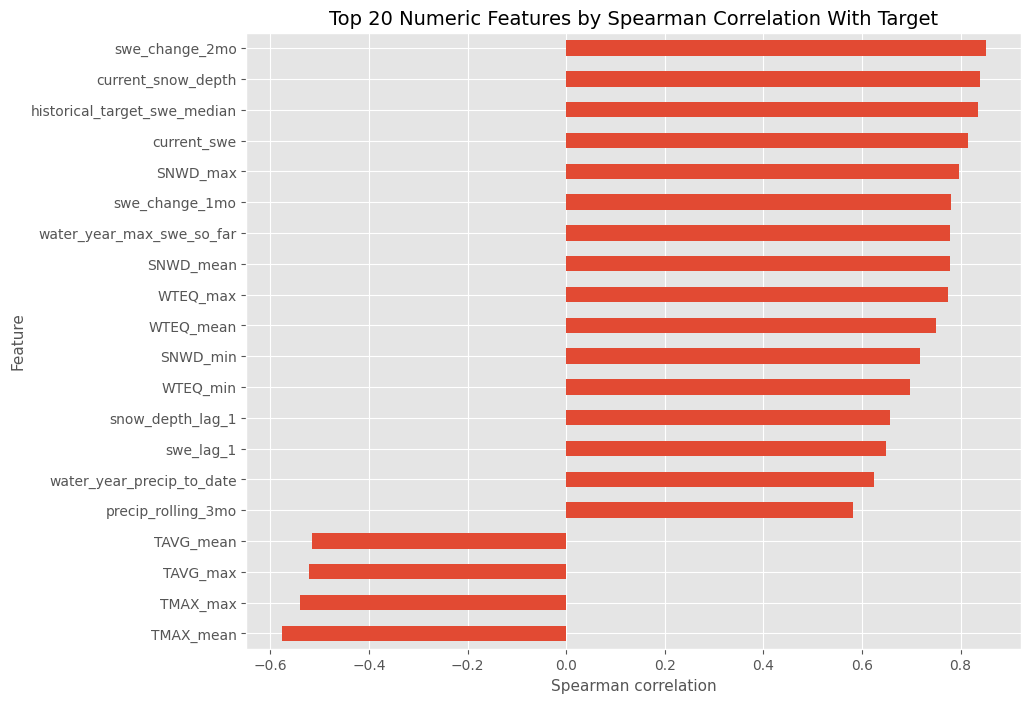

In [ ]:
pearson = df[numeric_features + [TARGET]].corr(method='pearson')[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
spearman = df[numeric_features + [TARGET]].corr(method='spearman')[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)

corr_table = pd.concat([
    pearson.rename('pearson_corr'),
    spearman.rename('spearman_corr'),
], axis=1)
corr_table['abs_pearson'] = corr_table['pearson_corr'].abs()
corr_table['abs_spearman'] = corr_table['spearman_corr'].abs()
corr_table = corr_table.sort_values('abs_spearman', ascending=False)

display(corr_table.head(30))

top_corr = corr_table.head(20).sort_values('spearman_corr')
fig, ax = plt.subplots(figsize=(10, 8))
top_corr['spearman_corr'].plot(kind='barh', ax=ax)
ax.set_title('Top 20 Numeric Features by Spearman Correlation With Target')
ax.set_xlabel('Spearman correlation')
ax.set_ylabel('Feature')
plt.show()


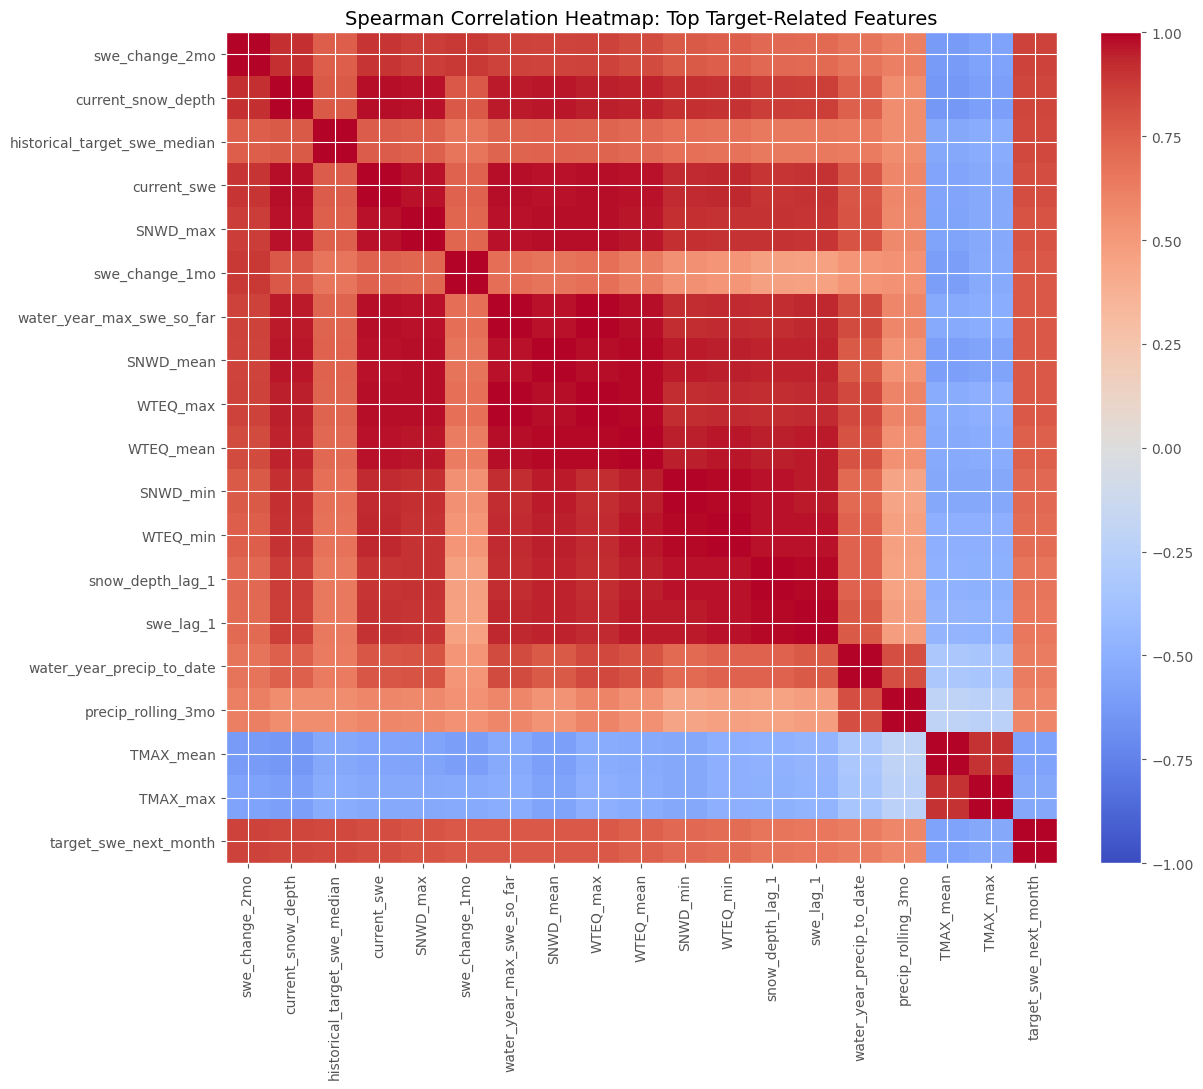

,feature_1,feature_2,spearman_corr,abs_corr
122,water_year_max_swe_so_far,WTEQ_max,0.993,0.993
142,SNWD_mean,WTEQ_mean,0.989,0.989
241,snow_depth_lag_1,swe_lag_1,0.988,0.988
161,WTEQ_max,WTEQ_mean,0.987,0.987
201,SNWD_min,WTEQ_min,0.987,0.987
63,current_swe,water_year_max_swe_so_far,0.983,0.983
123,water_year_max_swe_so_far,WTEQ_mean,0.982,0.982
84,SNWD_max,WTEQ_max,0.981,0.981
22,current_snow_depth,current_swe,0.980,0.980
65,current_swe,WTEQ_max,0.979,0.979


In [ ]:
top_features = corr_table.head(18).index.tolist()
corr_matrix = df[top_features + [TARGET]].corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title('Spearman Correlation Heatmap: Top Target-Related Features')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_pairs = (
    upper.stack()
      .rename('spearman_corr')
      .reset_index()
      .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
)
high_pairs['abs_corr'] = high_pairs['spearman_corr'].abs()
display(high_pairs[high_pairs['abs_corr'] >= 0.85].sort_values('abs_corr', ascending=False).head(40))


## 8. Deep Dive on the Most Important Numeric Features

This section looks more closely at the strongest target-related features. The plots are sampled for readability but the summary tables use the full dataset.


Key features selected from correlation screen:
['swe_change_2mo', 'current_snow_depth', 'historical_target_swe_median', 'current_swe', 'SNWD_max', 'swe_change_1mo', 'water_year_max_swe_so_far', 'SNWD_mean']


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
swe_change_2mo,"88,049.000",4.996,5.677,-15.400,-3.700,0.000,1.000,3.600,7.100,15.900,25.700,74.800
current_snow_depth,"86,239.000",28.765,27.558,0.000,0.000,0.000,6.000,23.000,43.000,82.000,119.000,264.000
historical_target_swe_median,"88,049.000",10.897,10.751,0.000,0.000,0.000,3.600,8.000,14.500,32.300,50.700,117.900
current_swe,"88,049.000",8.549,9.806,0.000,0.000,0.000,1.500,5.700,12.000,27.700,45.400,118.600
SNWD_max,"86,239.000",33.484,29.304,0.000,0.000,0.000,10.000,28.000,49.000,90.000,129.000,270.000
swe_change_1mo,"88,049.000",2.672,3.457,-17.300,-4.500,-0.500,0.500,1.900,3.900,9.000,15.200,42.100
water_year_max_swe_so_far,"88,049.000",8.719,9.766,0.000,0.000,0.000,1.800,5.900,12.200,27.700,45.400,118.600
SNWD_mean,"86,239.000",25.089,25.522,0.000,0.000,0.000,3.500,18.774,38.355,74.677,109.548,250.903
target_swe_next_month,"88,049.000",10.560,11.020,0.000,0.000,0.000,3.000,7.500,14.400,32.200,51.900,123.700


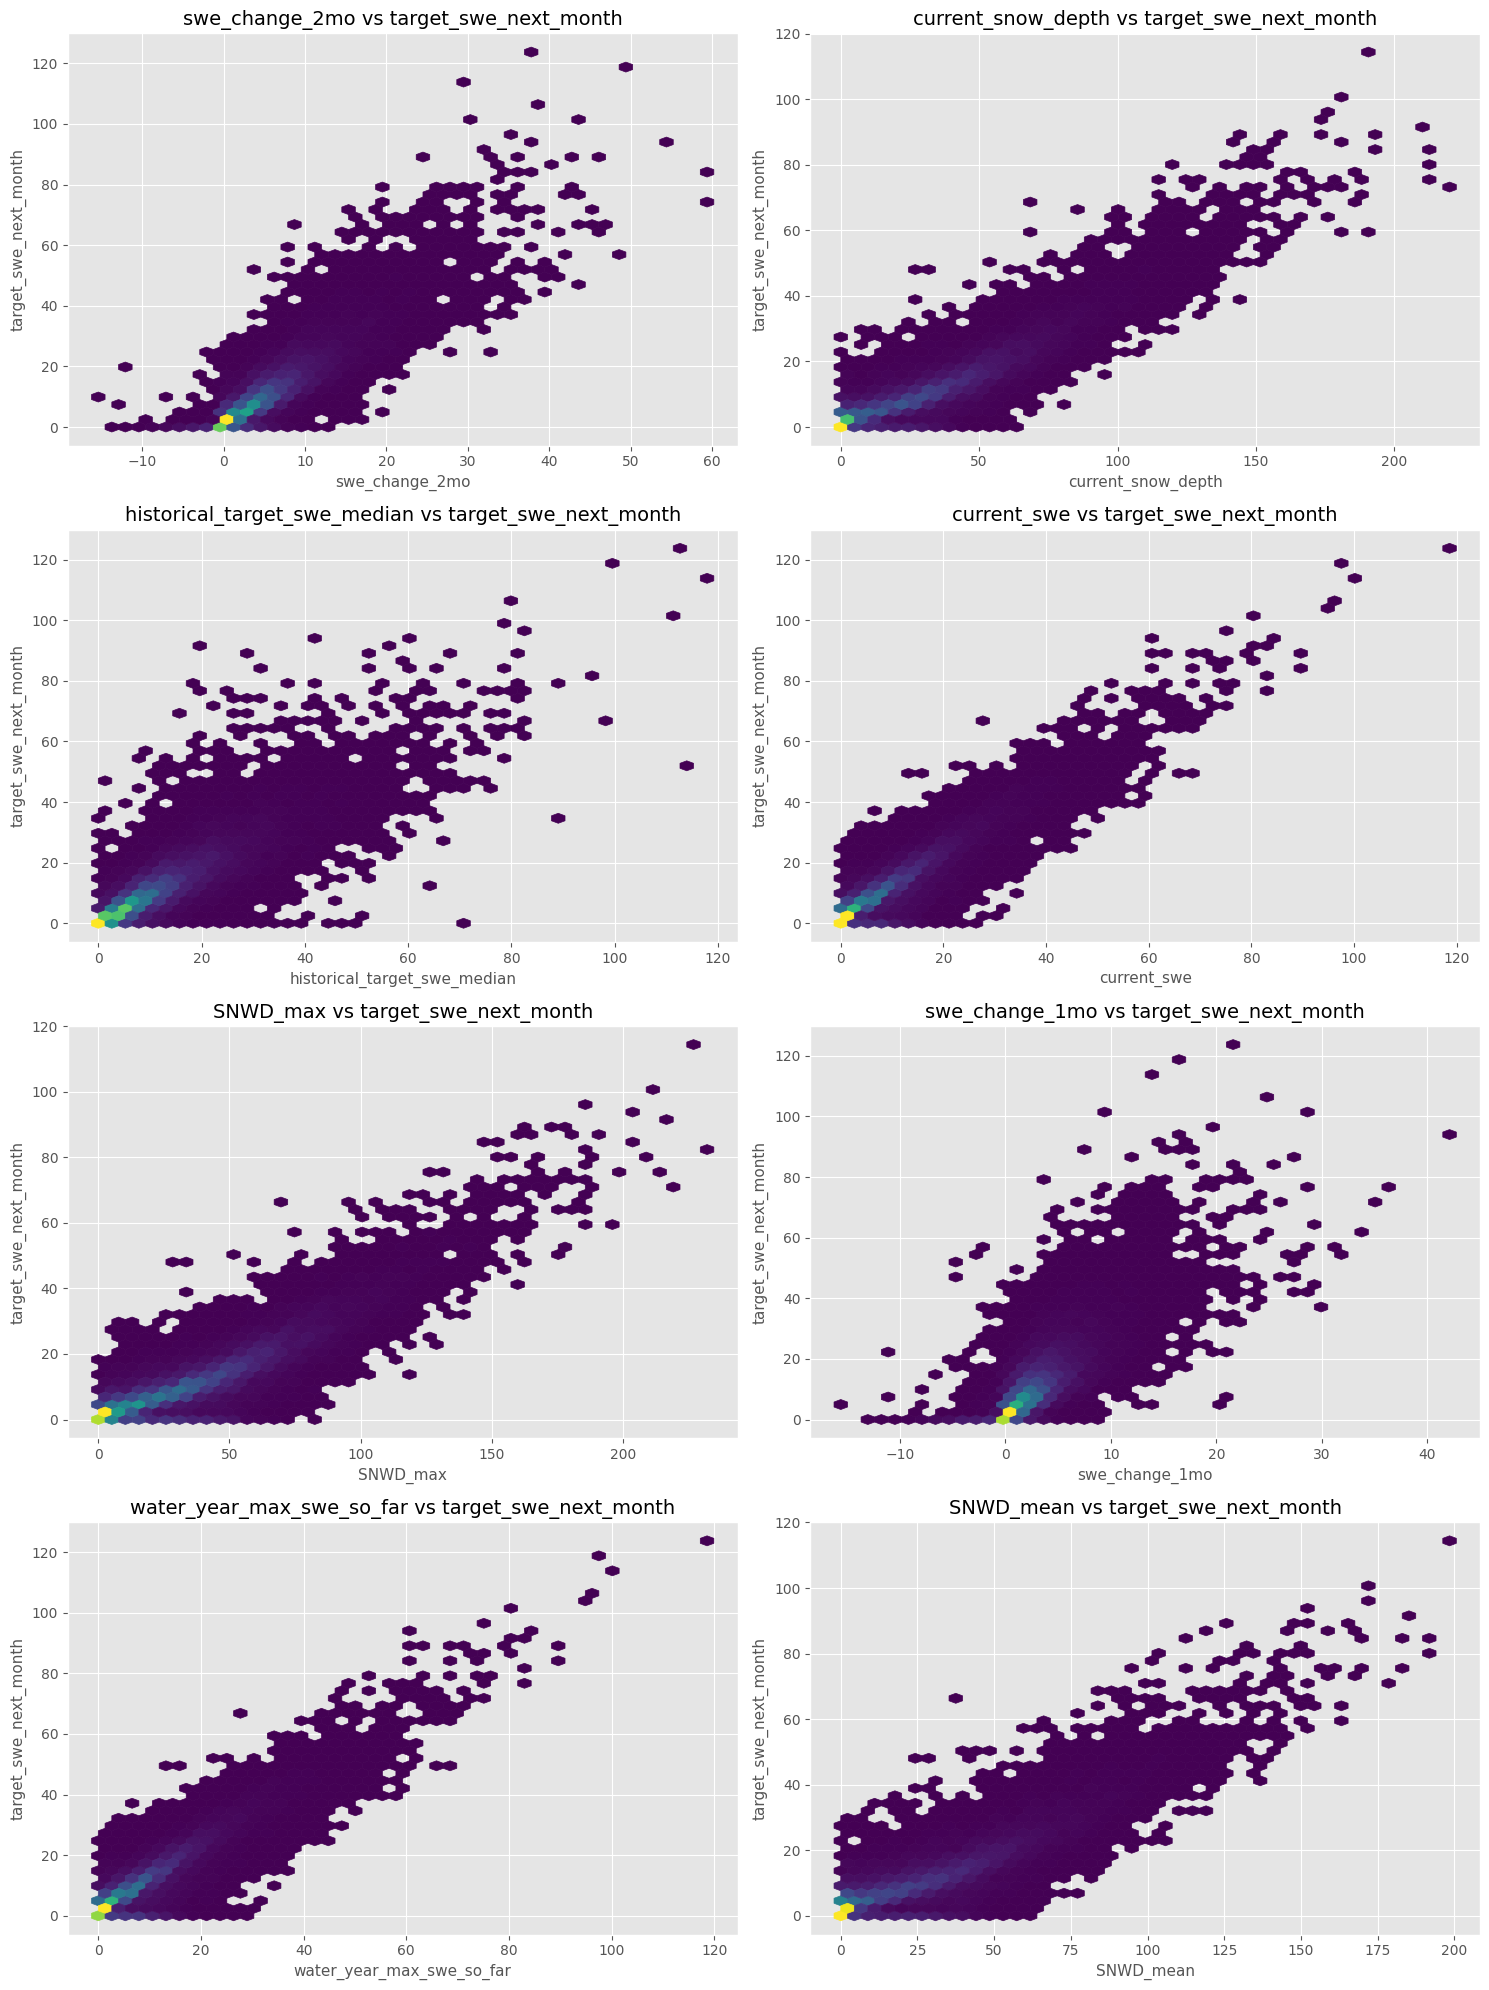

In [ ]:
key_features = [col for col in corr_table.head(8).index if col in df.columns]
print('Key features selected from correlation screen:')
print(key_features)

display(numeric_summary(df, key_features + [TARGET]))

sample_n = min(25000, len(df))
plot_df = df.sample(sample_n, random_state=42)

ncols = 2
nrows = int(np.ceil(len(key_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, feature in zip(axes, key_features):
    ax.hexbin(plot_df[feature], plot_df[TARGET], gridsize=45, mincnt=1, cmap='viridis')
    ax.set_title(f'{feature} vs {TARGET}')
    ax.set_xlabel(feature)
    ax.set_ylabel(TARGET)

for ax in axes[len(key_features):]:
    ax.set_axis_off()

plt.tight_layout()
plt.show()


,swe_change_2mo,current_snow_depth,historical_target_swe_median,current_swe,SNWD_max,swe_change_1mo,water_year_max_swe_so_far,SNWD_mean
target_month,,,,,,,,
1,0.898,0.862,0.771,0.913,0.868,0.812,0.913,0.853
2,0.883,0.911,0.789,0.949,0.918,0.767,0.947,0.917
3,0.845,0.931,0.804,0.942,0.931,0.758,0.938,0.934
4,0.816,0.921,0.817,0.887,0.872,0.766,0.857,0.897
11,0.530,0.512,0.612,0.530,0.456,0.517,0.530,0.466
12,0.726,0.685,0.721,0.726,0.700,0.686,0.729,0.632


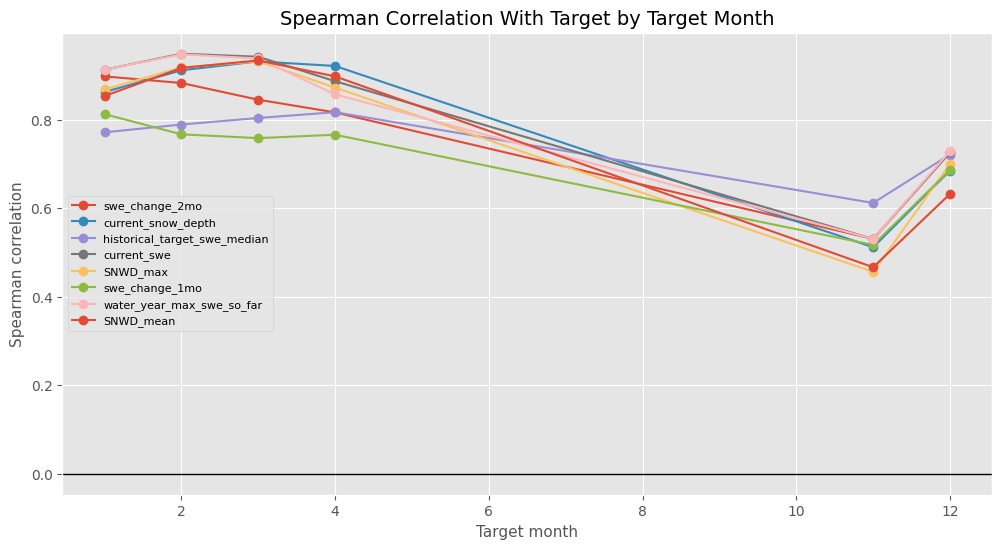

In [ ]:
feature_month_rows = []
for feature in key_features:
    temp = (
        df.assign(target_month=df['target_month_end'].dt.month)
          .groupby('target_month')
          .apply(lambda g: g[[feature, TARGET]].corr(method='spearman').iloc[0, 1], include_groups=False)
          .rename(feature)
    )
    feature_month_rows.append(temp)

feature_month_corr = pd.concat(feature_month_rows, axis=1)
display(feature_month_corr)

fig, ax = plt.subplots(figsize=(12, 6))
for feature in feature_month_corr.columns:
    ax.plot(feature_month_corr.index, feature_month_corr[feature], marker='o', label=feature)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Spearman Correlation With Target by Target Month')
ax.set_xlabel('Target month')
ax.set_ylabel('Spearman correlation')
ax.legend(loc='best', fontsize=8)
plt.show()


## 9. Historical Median Feature Evaluation

`historical_target_swe_median` is a strong baseline-style feature: for each station and target date, it summarizes what historically happened before that target year. This section evaluates how much predictive power it has by itself.


rows                           88,049.000
MAE                                 3.707
RMSE                                6.111
R2                                  0.692
mean_error_actual_minus_pred       -0.337
median_abs_error                    2.100
dtype: float64

,rows,actual_mean,hist_median_mean,MAE,bias_actual_minus_pred
target_month,,,,,
1,14208,10.609,10.815,3.225,-0.206
2,14038,13.980,14.583,4.250,-0.603
3,14897,16.455,16.986,5.309,-0.531
4,14905,12.970,13.323,5.557,-0.353
11,14952,2.794,2.845,1.502,-0.051
12,15049,6.817,7.106,2.427,-0.289


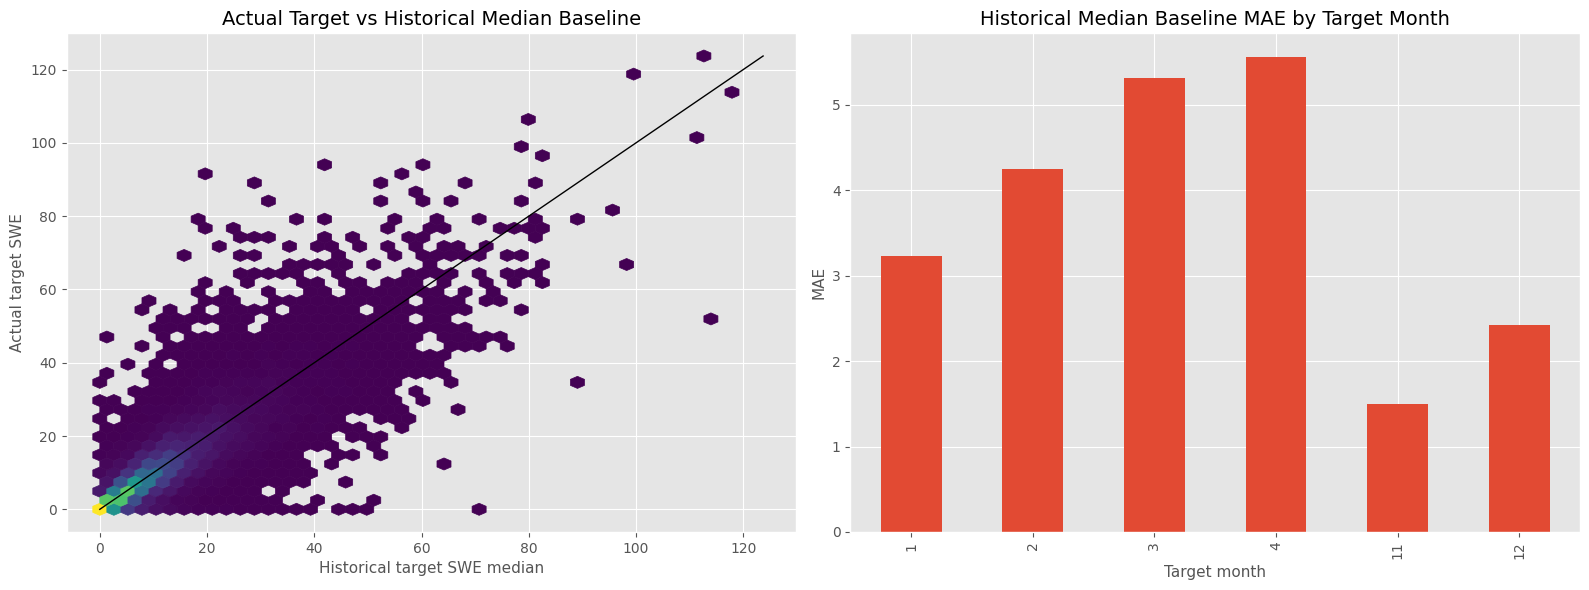

In [ ]:
baseline_df = df.dropna(subset=[TARGET, 'historical_target_swe_median']).copy()
y_true = baseline_df[TARGET].to_numpy()
y_pred = baseline_df['historical_target_swe_median'].to_numpy()

baseline_metrics = pd.Series({
    'rows': len(baseline_df),
    'MAE': mae(y_true, y_pred),
    'RMSE': rmse(y_true, y_pred),
    'R2': r2_score(y_true, y_pred),
    'mean_error_actual_minus_pred': float(np.mean(y_true - y_pred)),
    'median_abs_error': float(np.median(np.abs(y_true - y_pred))),
})
display(baseline_metrics)

baseline_by_month = (
    baseline_df.assign(
        target_month=baseline_df['target_month_end'].dt.month,
        abs_error=(baseline_df[TARGET] - baseline_df['historical_target_swe_median']).abs(),
        error=baseline_df[TARGET] - baseline_df['historical_target_swe_median'],
    )
    .groupby('target_month')
    .agg(
        rows=(TARGET, 'size'),
        actual_mean=(TARGET, 'mean'),
        hist_median_mean=('historical_target_swe_median', 'mean'),
        MAE=('abs_error', 'mean'),
        bias_actual_minus_pred=('error', 'mean'),
    )
)
display(baseline_by_month)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_df = baseline_df.sample(min(25000, len(baseline_df)), random_state=42)
axes[0].hexbin(plot_df['historical_target_swe_median'], plot_df[TARGET], gridsize=45, mincnt=1, cmap='viridis')
max_val = np.nanmax([plot_df['historical_target_swe_median'].max(), plot_df[TARGET].max()])
axes[0].plot([0, max_val], [0, max_val], color='black', linewidth=1)
axes[0].set_title('Actual Target vs Historical Median Baseline')
axes[0].set_xlabel('Historical target SWE median')
axes[0].set_ylabel('Actual target SWE')

baseline_by_month['MAE'].plot(kind='bar', ax=axes[1])
axes[1].set_title('Historical Median Baseline MAE by Target Month')
axes[1].set_xlabel('Target month')
axes[1].set_ylabel('MAE')
plt.tight_layout()
plt.show()


## 10. Temperature, Precipitation, and Snowpack Feature Groups

Snowpack prediction is physically driven by existing snowpack, precipitation accumulation, temperature, and seasonality. This section summarizes those feature families so modeling decisions are not based on correlation alone.


In [ ]:
feature_groups = {
    'snowpack': [col for col in df.columns if any(token in col.lower() for token in ['swe', 'wteq', 'snow_depth', 'snwd']) and col != TARGET],
    'precipitation': [col for col in df.columns if 'precip' in col.lower()],
    'temperature': [col for col in df.columns if col.startswith(('TAVG', 'TMIN', 'TMAX')) or col in ['avg_temp_above_freezing', 'freeze_thaw_risk']],
    'seasonality_time': [col for col in ['month', 'year', 'day_of_year', 'month_sin', 'month_cos', 'is_winter', 'is_spring', 'water_year'] if col in df.columns],
    'geography': [col for col in ['elevation', 'latitude', 'longitude'] if col in df.columns],
}

for group_name, cols in feature_groups.items():
    cols = [col for col in cols if col in numeric_features]
    if not cols:
        continue
    group_corr = corr_table.loc[corr_table.index.intersection(cols)].sort_values('abs_spearman', ascending=False)
    print('\n' + group_name.upper())
    display(group_corr[['pearson_corr', 'spearman_corr']].head(15))



SNOWPACK


,pearson_corr,spearman_corr
swe_change_2mo,0.871,0.852
current_snow_depth,0.896,0.840
historical_target_swe_median,0.843,0.835
current_swe,0.903,0.814
SNWD_max,0.874,0.796
swe_change_1mo,0.757,0.781
water_year_max_swe_so_far,0.892,0.778
SNWD_mean,0.859,0.778
WTEQ_max,0.888,0.775
WTEQ_mean,0.861,0.749



PRECIPITATION


,pearson_corr,spearman_corr
water_year_precip_to_date,0.666,0.625
precip_rolling_3mo,0.609,0.583
precip_lag_1,0.527,0.493
monthly_precip,0.494,0.482
precip_lag_2,0.532,0.437



TEMPERATURE


,pearson_corr,spearman_corr
TMAX_mean,-0.376,-0.577
TMAX_max,-0.370,-0.540
TAVG_max,-0.350,-0.521
TAVG_mean,-0.310,-0.516
avg_temp_above_freezing,-0.344,-0.499
TMIN_mean,-0.211,-0.401
TAVG_min,-0.185,-0.384
TMIN_min,-0.138,-0.315
freeze_thaw_risk,-0.100,-0.158
TAVG_std,-0.092,-0.003



SEASONALITY_TIME


,pearson_corr,spearman_corr
is_winter,0.281,0.403
month_sin,0.394,0.363
month,-0.326,-0.235
day_of_year,-0.326,-0.232
month_cos,-0.063,0.142
water_year,-0.062,-0.066
year,-0.029,-0.035
is_spring,0.099,0.002



GEOGRAPHY


,pearson_corr,spearman_corr
latitude,0.119,0.185
longitude,-0.064,-0.058
elevation,-0.040,0.039


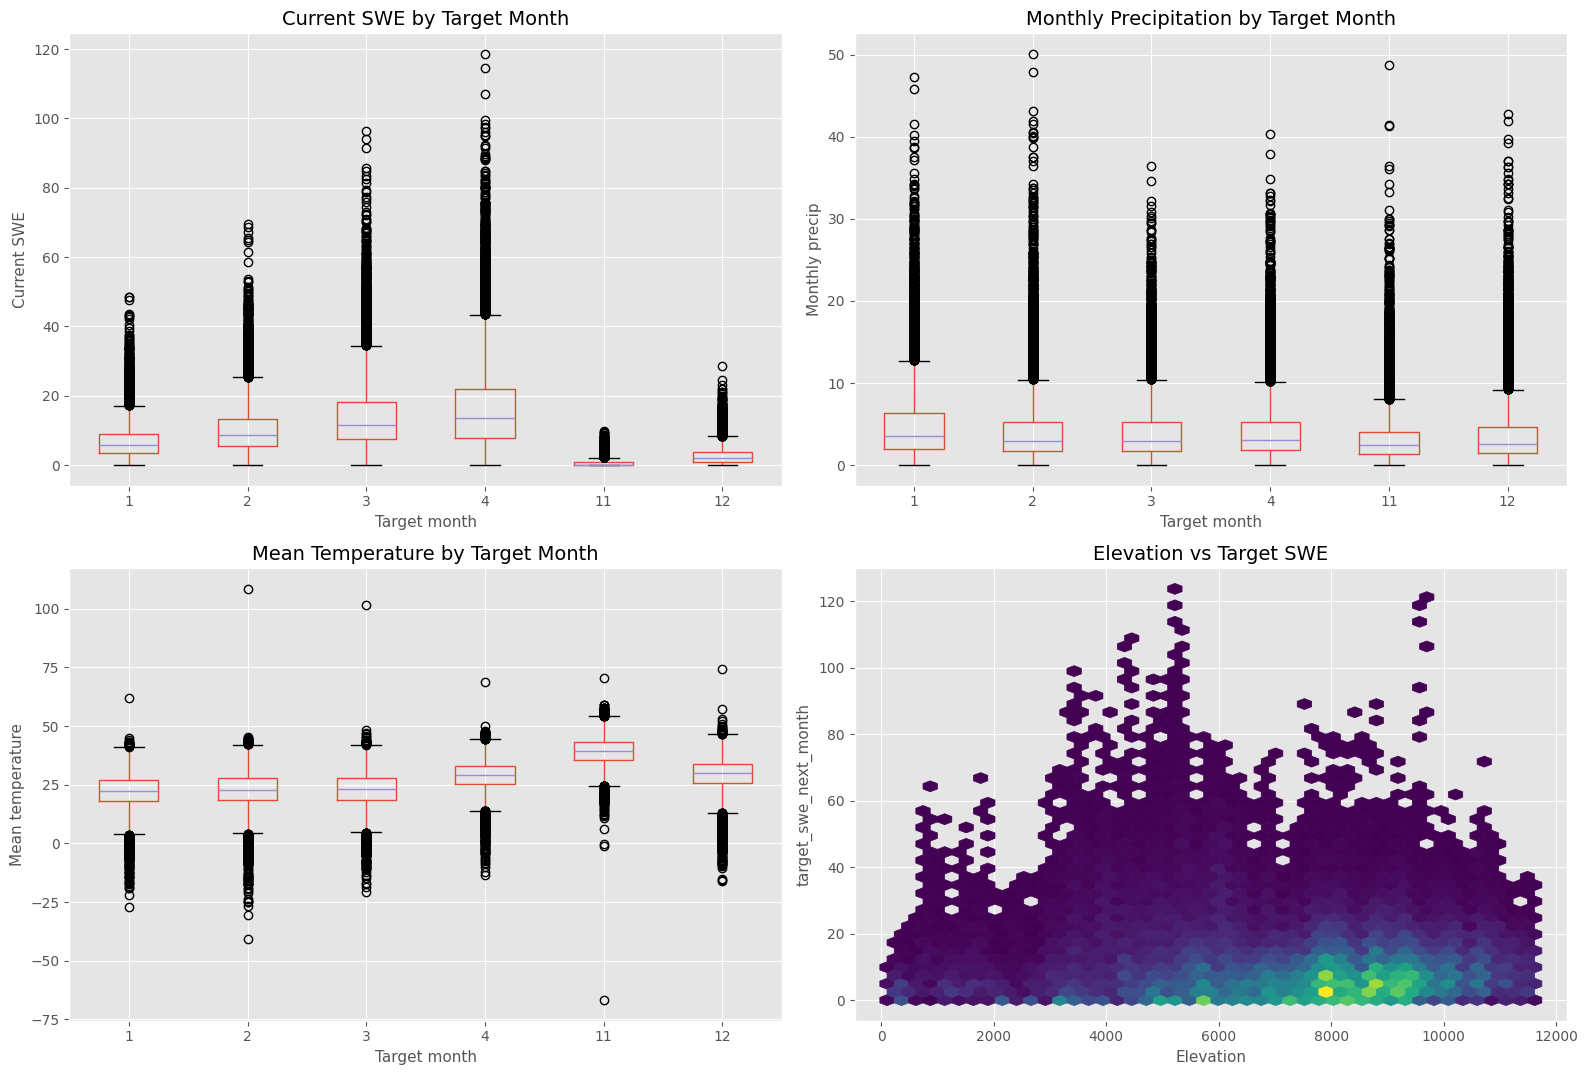

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

if 'current_swe' in df.columns:
    df.assign(target_month=df['target_month_end'].dt.month).boxplot(column='current_swe', by='target_month', ax=axes[0, 0])
    axes[0, 0].set_title('Current SWE by Target Month')
    axes[0, 0].set_xlabel('Target month')
    axes[0, 0].set_ylabel('Current SWE')

if 'monthly_precip' in df.columns:
    df.assign(target_month=df['target_month_end'].dt.month).boxplot(column='monthly_precip', by='target_month', ax=axes[0, 1])
    axes[0, 1].set_title('Monthly Precipitation by Target Month')
    axes[0, 1].set_xlabel('Target month')
    axes[0, 1].set_ylabel('Monthly precip')

if 'TAVG_mean' in df.columns:
    df.assign(target_month=df['target_month_end'].dt.month).boxplot(column='TAVG_mean', by='target_month', ax=axes[1, 0])
    axes[1, 0].set_title('Mean Temperature by Target Month')
    axes[1, 0].set_xlabel('Target month')
    axes[1, 0].set_ylabel('Mean temperature')

if 'elevation' in df.columns:
    axes[1, 1].hexbin(df['elevation'], df[TARGET], gridsize=45, mincnt=1, cmap='viridis')
    axes[1, 1].set_title('Elevation vs Target SWE')
    axes[1, 1].set_xlabel('Elevation')
    axes[1, 1].set_ylabel(TARGET)

plt.suptitle('')
plt.tight_layout()
plt.show()


## 11. Categorical and Geographic EDA

State, county, and station-level differences can be large. This section checks whether the target varies systematically across geography, which can motivate geographic features, station effects, or grouped validation strategies.


,rows,stations,mean,median,std,p95,zero_pct
stateCode,,,,,,,
WA,7789,76,19.010,13.900,18.214,55.500,6.856
CA,3679,34,13.085,8.300,15.066,44.800,11.851
ID,9135,83,12.586,9.700,11.267,35.300,5.594
MT,10030,92,11.278,8.500,9.929,32.100,2.851
WY,9666,89,10.670,8.400,8.552,28.000,1.583
CO,12324,116,9.875,8.300,7.613,23.800,3.092
OR,8890,81,9.770,6.200,11.301,32.755,16.850
UT,12931,135,8.757,6.800,8.254,24.500,8.290
AK,4040,54,8.116,5.400,8.351,24.900,4.084


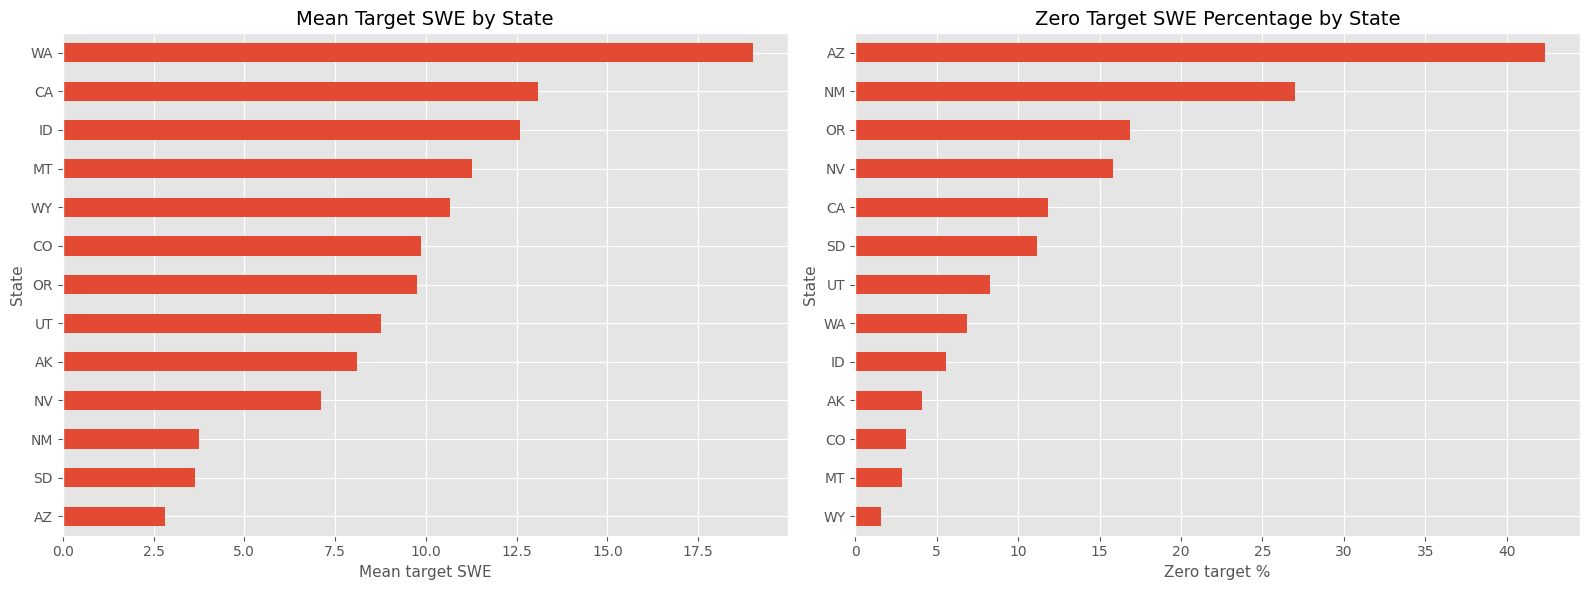

In [ ]:
state_target = (
    df.groupby('stateCode')[TARGET]
      .agg(rows='size', stations=lambda s: df.loc[s.index, 'station_triplet'].nunique(), mean='mean', median='median', std='std', p95=lambda s: s.quantile(0.95), zero_pct=lambda s: (s == 0).mean() * 100)
      .sort_values('mean', ascending=False)
)
display(state_target)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
state_target['mean'].sort_values().plot(kind='barh', ax=axes[0])
axes[0].set_title('Mean Target SWE by State')
axes[0].set_xlabel('Mean target SWE')
axes[0].set_ylabel('State')

state_target['zero_pct'].sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('Zero Target SWE Percentage by State')
axes[1].set_xlabel('Zero target %')
axes[1].set_ylabel('State')
plt.tight_layout()
plt.show()


Highest mean-SWE stations with at least 50 rows:


,station_triplet,name,stateCode,rows,mean_target,median_target,std_target,max_target,mean_elevation
856,998:WA:SNTL,Easy Pass,WA,79,58.973,61.000,30.585,123.700,"5,280.000"
577,679:WA:SNTL,Paradise,WA,112,46.949,46.700,27.268,104.500,"5,150.000"
10,1012:WA:SNTL,Swift Creek,WA,110,45.308,47.050,28.409,110.400,"4,440.000"
57,1080:WA:SNTL,Brown Top,WA,84,39.145,38.350,19.660,80.000,"5,850.000"
509,606:WA:SNTL,Lyman Lake,WA,112,37.167,37.600,18.175,74.900,"5,990.000"
9,1011:WA:SNTL,MF Nooksack,WA,112,36.907,34.800,23.885,91.200,"4,940.000"
62,1085:WA:SNTL,Cayuse Pass,WA,102,35.995,37.250,21.912,85.100,"5,260.000"
479,574:CA:SNTL,Leavitt Lake,CA,112,34.406,31.600,26.184,121.400,"9,600.000"
543,642:WA:SNTL,Morse Lake,WA,112,34.254,37.350,18.036,70.800,"5,400.000"
857,999:WA:SNTL,Marten Ridge,WA,103,34.040,31.000,23.095,88.200,"3,520.000"


Highest target variability stations with at least 50 rows:


,station_triplet,name,stateCode,rows,mean_target,median_target,std_target,max_target,mean_elevation
856,998:WA:SNTL,Easy Pass,WA,79,58.973,61.000,30.585,123.700,"5,280.000"
10,1012:WA:SNTL,Swift Creek,WA,110,45.308,47.050,28.409,110.400,"4,440.000"
577,679:WA:SNTL,Paradise,WA,112,46.949,46.700,27.268,104.500,"5,150.000"
479,574:CA:SNTL,Leavitt Lake,CA,112,34.406,31.600,26.184,121.400,"9,600.000"
9,1011:WA:SNTL,MF Nooksack,WA,112,36.907,34.800,23.885,91.200,"4,940.000"
857,999:WA:SNTL,Marten Ridge,WA,103,34.040,31.000,23.095,88.200,"3,520.000"
783,908:WA:SNTL,Alpine Meadows,WA,112,30.704,27.050,22.630,93.200,"3,500.000"
81,1107:WA:SNTL,Buckinghorse,WA,90,33.897,35.950,21.930,95.000,"4,850.000"
62,1085:WA:SNTL,Cayuse Pass,WA,102,35.995,37.250,21.912,85.100,"5,260.000"
459,553:WA:SNTL,June Lake,WA,112,28.966,27.300,20.894,97.400,"3,440.000"


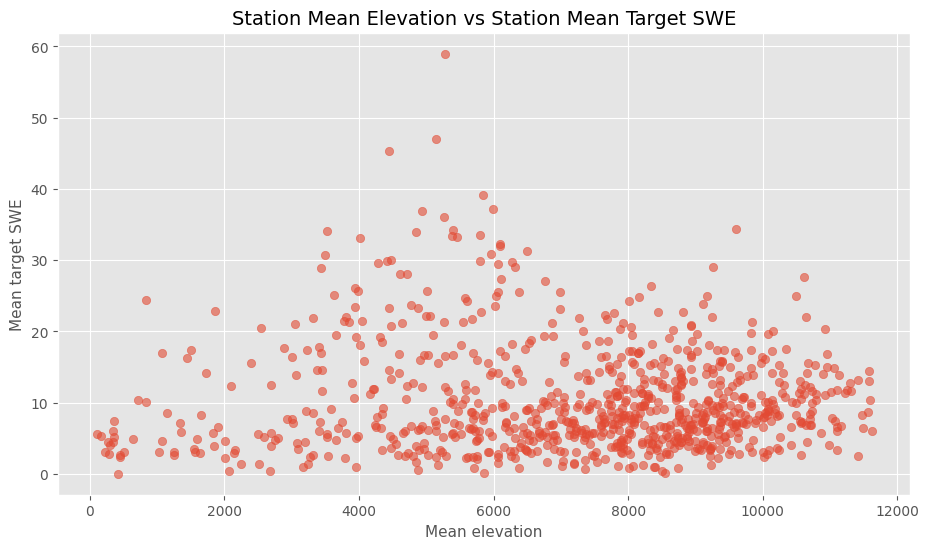

In [ ]:
station_target = (
    df.groupby(['station_triplet', 'name', 'stateCode'])
      .agg(
          rows=(TARGET, 'size'),
          mean_target=(TARGET, 'mean'),
          median_target=(TARGET, 'median'),
          std_target=(TARGET, 'std'),
          max_target=(TARGET, 'max'),
          mean_elevation=('elevation', 'mean'),
      )
      .reset_index()
)

print('Highest mean-SWE stations with at least 50 rows:')
display(station_target[station_target['rows'] >= 50].sort_values('mean_target', ascending=False).head(20))

print('Highest target variability stations with at least 50 rows:')
display(station_target[station_target['rows'] >= 50].sort_values('std_target', ascending=False).head(20))

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(station_target['mean_elevation'], station_target['mean_target'], alpha=0.6)
ax.set_title('Station Mean Elevation vs Station Mean Target SWE')
ax.set_xlabel('Mean elevation')
ax.set_ylabel('Mean target SWE')
plt.show()


## 12. Outlier and Extreme Value Analysis

Extreme SWE values may be real hydrologic events rather than bad data. This section identifies high-end targets and high-end feature values so model evaluation can account for rare but important cases.


In [ ]:
target_quantiles = df[TARGET].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.995, 1.0]).to_frame('target_swe_next_month')
display(target_quantiles)

extreme_cutoff = df[TARGET].quantile(0.99)
extreme = df[df[TARGET] >= extreme_cutoff].copy()
print(f'99th percentile cutoff: {extreme_cutoff:.2f}')
print(f'Extreme rows: {len(extreme):,}')

display(
    extreme[['station_triplet', 'name', 'stateCode', 'month_end', 'target_month_end', TARGET, 'current_swe', 'historical_target_swe_median', 'elevation']]
    .sort_values(TARGET, ascending=False)
    .head(25)
)

extreme_by_month_state = (
    extreme.assign(target_month=extreme['target_month_end'].dt.month)
      .groupby(['target_month', 'stateCode'])
      .size()
      .rename('extreme_rows')
      .reset_index()
      .sort_values('extreme_rows', ascending=False)
)
display(extreme_by_month_state.head(30))


,target_swe_next_month
0.500,7.500
0.750,14.400
0.900,24.000
0.950,32.200
0.990,51.900
0.995,60.076
1.000,123.700


99th percentile cutoff: 51.90
Extreme rows: 889


,station_triplet,name,stateCode,month_end,target_month_end,target_swe_next_month,current_swe,historical_target_swe_median,elevation
87871,998:WA:SNTL,Easy Pass,WA,2012-03-31,2012-04-30,123.700,118.600,112.100,"5,280.000"
46147,574:CA:SNTL,Leavitt Lake,CA,2017-03-31,2017-04-30,121.400,107.100,44.700,"9,600.000"
87870,998:WA:SNTL,Easy Pass,WA,2012-02-29,2012-03-31,118.600,96.400,98.300,"5,280.000"
46183,574:CA:SNTL,Leavitt Lake,CA,2023-03-31,2023-04-30,117.300,114.500,44.700,"9,600.000"
46182,574:CA:SNTL,Leavitt Lake,CA,2023-02-28,2023-03-31,114.500,83.300,48.800,"9,600.000"
87877,998:WA:SNTL,Easy Pass,WA,2013-03-31,2013-04-30,114.400,99.600,117.900,"5,280.000"
87895,998:WA:SNTL,Easy Pass,WA,2017-03-31,2017-04-30,111.500,97.500,112.100,"5,280.000"
1114,1012:WA:SNTL,Swift Creek,WA,2017-03-31,2017-04-30,110.400,94.900,71.300,"4,440.000"
87925,998:WA:SNTL,Easy Pass,WA,2022-03-31,2022-04-30,107.400,91.400,98.600,"5,280.000"
46146,574:CA:SNTL,Leavitt Lake,CA,2017-02-28,2017-03-31,107.100,94.200,48.900,"9,600.000"


,target_month,stateCode,extreme_rows
26,4,WA,204
17,3,WA,199
8,2,WA,68
10,3,CA,54
19,4,CA,45
21,4,ID,44
12,3,ID,42
24,4,OR,37
22,4,MT,33
15,3,OR,28


In [ ]:
outlier_rows = []
for col in numeric_features:
    s = df[col].dropna()
    if s.empty:
        continue
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        continue
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_rows.append({
        'feature': col,
        'lower_iqr_fence': lower,
        'upper_iqr_fence': upper,
        'outlier_count': int(((df[col] < lower) | (df[col] > upper)).sum()),
        'outlier_pct': float(((df[col] < lower) | (df[col] > upper)).mean() * 100),
        'min': float(s.min()),
        'max': float(s.max()),
    })

outlier_table = pd.DataFrame(outlier_rows).sort_values('outlier_pct', ascending=False)
display(outlier_table.head(30))


,feature,lower_iqr_fence,upper_iqr_fence,outlier_count,outlier_pct,min,max
26,swe_lag_3,-3.300,5.500,9781,11.109,0.000,48.600
30,precip_rolling_3mo,-6.050,24.750,7369,8.369,0.000,135.800
28,precip_lag_1,-3.400,9.400,6536,7.423,0.000,111.600
29,precip_lag_2,-3.300,8.700,6438,7.312,0.000,111.600
8,monthly_precip,-3.400,10.200,6361,7.224,0.000,50.100
33,water_year_precip_to_date,-14.500,36.700,6267,7.118,0.000,194.300
25,swe_lag_2,-7.800,13.000,5840,6.633,0.000,80.200
31,swe_change_1mo,-4.600,9.000,5221,5.930,-17.300,42.100
40,historical_target_swe_median,-12.750,30.850,4985,5.662,0.000,117.900
3,WTEQ_max,-13.700,27.900,4409,5.007,0.000,118.600


## 13. Modeling Risk Checks

This final EDA section turns observations into regression-model implications: target skew, zero inflation, station grouping, high feature collinearity, baseline strength, and validation design.


In [ ]:
summary_rows = []
summary_rows.append({'check': 'rows', 'value': len(df)})
summary_rows.append({'check': 'stations', 'value': df['station_triplet'].nunique()})
summary_rows.append({'check': 'states', 'value': df['stateCode'].nunique()})
summary_rows.append({'check': 'target_zero_pct', 'value': (df[TARGET] == 0).mean() * 100})
summary_rows.append({'check': 'target_skew', 'value': df[TARGET].skew()})
summary_rows.append({'check': 'max_column_missing_pct', 'value': df.isna().mean().max() * 100})
summary_rows.append({'check': 'historical_median_missing_pct', 'value': df['historical_target_swe_median'].isna().mean() * 100})
summary_rows.append({'check': 'historical_median_baseline_mae', 'value': baseline_metrics['MAE']})
summary_rows.append({'check': 'historical_median_baseline_rmse', 'value': baseline_metrics['RMSE']})
summary_rows.append({'check': 'historical_median_baseline_r2', 'value': baseline_metrics['R2']})

eda_summary = pd.DataFrame(summary_rows)
display(eda_summary)

print('Top positive Spearman correlations with target:')
display(spearman.sort_values(ascending=False).head(12).to_frame('spearman_corr'))

print('Top negative Spearman correlations with target:')
display(spearman.sort_values(ascending=True).head(12).to_frame('spearman_corr'))

print('High-collinearity pairs among top target-related features, if any:')
display(high_pairs[high_pairs['abs_corr'] >= 0.90].sort_values('abs_corr', ascending=False).head(20))


,check,value
0,rows,"88,049.000"
1,stations,858.000
2,states,13.000
3,target_zero_pct,8.486
4,target_skew,2.222
5,max_column_missing_pct,2.056
6,historical_median_missing_pct,0.000
7,historical_median_baseline_mae,3.707
8,historical_median_baseline_rmse,6.111
9,historical_median_baseline_r2,0.692


Top positive Spearman correlations with target:


,spearman_corr
swe_change_2mo,0.852
current_snow_depth,0.840
historical_target_swe_median,0.835
current_swe,0.814
SNWD_max,0.796
swe_change_1mo,0.781
water_year_max_swe_so_far,0.778
SNWD_mean,0.778
WTEQ_max,0.775
WTEQ_mean,0.749


Top negative Spearman correlations with target:


,spearman_corr
TMAX_mean,-0.577
TMAX_max,-0.540
TAVG_max,-0.521
TAVG_mean,-0.516
avg_temp_above_freezing,-0.499
TMIN_mean,-0.401
TAVG_min,-0.384
TMIN_min,-0.315
month,-0.235
day_of_year,-0.232


High-collinearity pairs among top target-related features, if any:


,feature_1,feature_2,spearman_corr,abs_corr
122,water_year_max_swe_so_far,WTEQ_max,0.993,0.993
142,SNWD_mean,WTEQ_mean,0.989,0.989
241,snow_depth_lag_1,swe_lag_1,0.988,0.988
161,WTEQ_max,WTEQ_mean,0.987,0.987
201,SNWD_min,WTEQ_min,0.987,0.987
63,current_swe,water_year_max_swe_so_far,0.983,0.983
123,water_year_max_swe_so_far,WTEQ_mean,0.982,0.982
84,SNWD_max,WTEQ_max,0.981,0.981
22,current_snow_depth,current_swe,0.980,0.980
65,current_swe,WTEQ_max,0.979,0.979


## 14. EDA Takeaway Prompts

Use the outputs above to write the final project narrative. In particular, focus on:

- Which features have the strongest relationship with next-month SWE.
- Whether the historical median is strong enough to be a baseline model.
- Whether target skew and zero inflation require transformed targets, robust losses, or separate zero/nonzero modeling.
- Whether high collinearity suggests regularized regression or careful feature selection.
- Whether station/state differences suggest grouped or time-based validation instead of random splits.
- Whether missingness is low enough for simple imputation or whether specific columns should be dropped.
